In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### 1. Download and load the Student Performance dataset.

In [4]:
math_data = pd.read_csv("student-mat.csv", sep = ";")

In [5]:
math_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
math_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
por_data = pd.read_csv("student-por.csv", sep = ";")

In [8]:
por_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [9]:
por_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [11]:
merged_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [12]:
math_data = math_data.rename(columns={
    math_data.columns[-3]: 'math_col_1',
    math_data.columns[-2]: 'math_col_2',
    math_data.columns[-1]: 'math_col_3'
})

por_data = por_data.rename(columns={
    por_data.columns[-3]: 'por_col_1',
    por_data.columns[-2]: 'por_col_2',
    por_data.columns[-1]: 'por_col_3'
})

merged_data = pd.merge(
    math_data,
    por_data,
    on=list(math_data.columns[:-3]),
    how='inner'
)

In [13]:
merged_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,math_col_1,math_col_2,math_col_3,por_col_1,por_col_2,por_col_3
0,GP,M,16,U,LE3,T,2,2,other,other,...,1,1,3,0,12,12,11,13,12,13
1,GP,M,15,U,GT3,A,2,2,other,other,...,1,1,3,0,14,16,16,14,14,15
2,GP,M,15,U,GT3,T,4,3,teacher,other,...,1,1,1,0,13,14,15,12,13,14
3,GP,M,15,U,GT3,T,4,4,health,health,...,1,1,5,0,12,15,15,11,12,12
4,GP,M,15,U,GT3,T,4,4,health,services,...,3,4,5,0,9,11,12,10,11,11


### 2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.


In [14]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      39 non-null     str  
 1   sex         39 non-null     str  
 2   age         39 non-null     int64
 3   address     39 non-null     str  
 4   famsize     39 non-null     str  
 5   Pstatus     39 non-null     str  
 6   Medu        39 non-null     int64
 7   Fedu        39 non-null     int64
 8   Mjob        39 non-null     str  
 9   Fjob        39 non-null     str  
 10  reason      39 non-null     str  
 11  guardian    39 non-null     str  
 12  traveltime  39 non-null     int64
 13  studytime   39 non-null     int64
 14  failures    39 non-null     int64
 15  schoolsup   39 non-null     str  
 16  famsup      39 non-null     str  
 17  paid        39 non-null     str  
 18  activities  39 non-null     str  
 19  nursery     39 non-null     str  
 20  higher      39 non-null     str  
 21  intern

In [15]:
categorical_cols = merged_data.select_dtypes(include='object').columns

encoded_data = pd.get_dummies(
    merged_data,
    columns=categorical_cols,
    drop_first=True
)

C:\Users\user\AppData\Local\Temp\ipykernel_7504\3381460679.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = merged_data.select_dtypes(include='object').columns


In [17]:
target_cols = ['math_col_1', 'math_col_2', 'math_col_3',
               'por_col_1', 'por_col_2', 'por_col_3']

feature_cols = encoded_data.columns.difference(target_cols)

scaler = StandardScaler()
scaled_data = encoded_data.copy()

scaled_data[feature_cols] = scaler.fit_transform(encoded_data[feature_cols])

## 3. Select appropriate input features and the target variable.

In [18]:
X = scaled_data.drop(columns=[
    'math_col_1', 'math_col_2', 'math_col_3',
    'por_col_1', 'por_col_2', 'por_col_3'
])

y = scaled_data['math_col_3']

## 4. Split the dataset into training and testing sets.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 5. Implement Linear Regression using the Gradient Descent algorithm.


In [21]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.cost_history = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Add intercept column
        X = np.c_[np.ones(X.shape[0]), X]

        self.weights = np.zeros(X.shape[1])
        m = len(y)

        for _ in range(self.n_iterations):
            predictions = X @ self.weights
            error = predictions - y

            # Gradient Descent update
            gradient = (1 / m) * (X.T @ error)
            self.weights -= self.learning_rate * gradient

            cost = (1 / (2 * m)) * np.sum(error ** 2)
            self.cost_history.append(cost)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights


# Train the model
model = LinearRegressionGD(learning_rate=0.01, n_iterations=2000)
model.fit(X_train, y_train)

# Predict final Mathematics grades
y_pred = model.predict(X_test)

## 6. Experiment with different learning rates and observe their effect on model convergence.

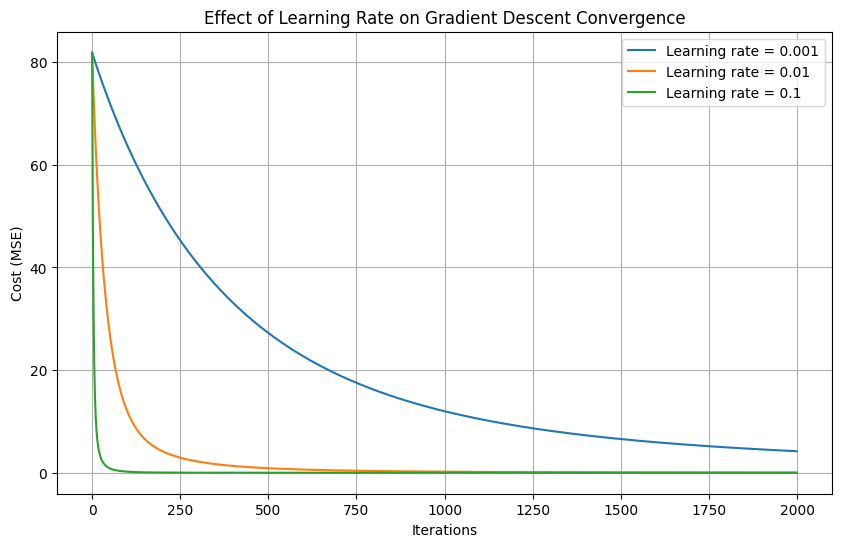

In [23]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = LinearRegressionGD(learning_rate=lr, n_iterations=2000)
    model.fit(X_train, y_train)

    plt.plot(model.cost_history, label=f'Learning rate = {lr}')

plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Effect of Learning Rate on Gradient Descent Convergence')
plt.legend()
plt.grid(True)
plt.show()

## 7. Plot the loss (cost) versus the number of iterations.


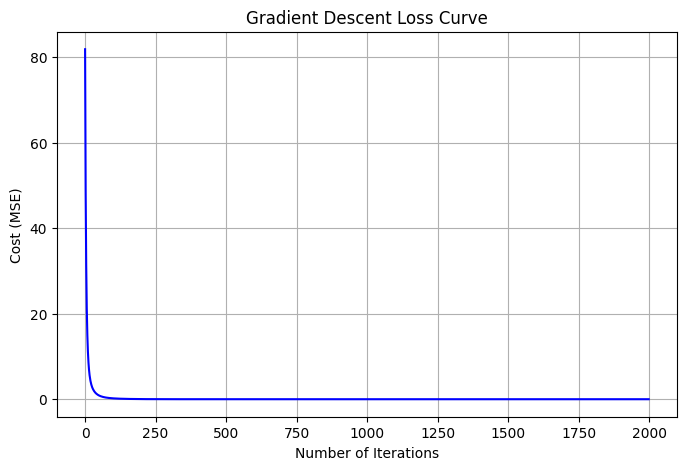

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(model.cost_history, color='blue')

plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Loss Curve')
plt.grid(True)
plt.show()

## 8. Evaluate the trained model using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score


In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE:  4.2685
MSE:  28.1603
RMSE: 5.3066
R² Score: -3.3428


## 9. Interpret the results and comment on the convergence behavior and prediction performance of the model.


The loss curves decrease smoothly without divergence, confirming that Gradient Descent is working correctly. A learning rate of 0.1 converges fastest, 0.01 converges more slowly, and 0.001 is still decreasing after 2,000 iterations. Therefore, 0.1 appears to be the most suitable of the tested learning rates.

However, the evaluation metrics show weak generalization on the test data. The MAE of 4.2685 means predictions are off by about 4.27 grade points on average. The RMSE of 5.3066 indicates relatively large prediction errors on a 0–20 grade scale.

The R² score of -3.3428 is the key concern. A negative R² means the model performs worse than a simple baseline that predicts the average final Mathematics grade for every student. Although training loss becomes very low, the model does not generalize well to unseen data, suggesting overfitting.